# AccentCat — StarGANv2-VC Real-time Accent Conversion Server


## Cell 1 — Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Cell 2 — Install dependencies

In [3]:
!pip install -q fastapi uvicorn websockets pydub soundfile pyngrok nest-asyncio munch
!pip install -q parallel_wavegan
!apt-get install -y -qq ffmpeg
!pip install -q scipy==1.11.4
!pip install numpy==1.26.4
print('Done.')

Done.


## Cell 3 — Configuration

In [7]:
# ==============================================================
# USER CONFIGURATION
# ==============================================================
WORK_DIR        = '/content/drive/MyDrive/Github/Accent-Conversion'
CHECKPOINT_PATH = 'Models/epoch_00150.pth'
CONFIG_YAML     = 'Models/config.yml'

# Vocoder paths — confirmed from your Vocoder/ directory listing
VOCODER_CONFIG  = 'Vocoder/config.yml'
VOCODER_CKPT    = 'Vocoder/checkpoint-400000steps.pkl'

# Fixed reference speaker for the demo (Data/p225/1.wav ~ 10.wav)
DEMO_REFS = {
    'p228': 'VCTK-corpus/p228/p228_023.wav',
    'p230': 'VCTK-corpus/p230/p230_023.wav',
    'p233': 'VCTK-corpus/p233/p233_023.wav',
    'p236': 'VCTK-corpus/p236/p236_023.wav',
    'p243': 'VCTK-corpus/p243/p243_023.wav',
    'p244': 'VCTK-corpus/p244/p244_023.wav',
    'p254': 'VCTK-corpus/p254/p254_023.wav',
    'p258': 'VCTK-corpus/p258/p258_023.wav',
    'p259': 'VCTK-corpus/p259/p259_023.wav',
    'p273': 'VCTK-corpus/p273/p273_023.wav',
}

NGROK_AUTH_TOKEN = '3BUOT4U5ZAcooHpRtdJlypPVZmo_5YiZj2TkVKS8A2WpkcNKV'
NGROK_DOMAIN     = 'indistinctively-nonhesitant-briggs.ngrok-free.dev'
SERVER_PORT      = 8000

print('Configuration set.')

Configuration set.


## Cell 4 — Load all models

In [18]:
import sys, os, io, yaml, torch, librosa
import subprocess
import numpy as np
import soundfile as sf
import torchaudio
from munch import Munch

sys.path.insert(0, WORK_DIR)
os.chdir(WORK_DIR)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

# ------------------------------------------------------------------
# Stage 1: Import project modules
# ------------------------------------------------------------------
print('[1] Importing project modules...')
from models import build_model
from Utils.JDC.model import JDCNet
from Utils.ASR.models import ASRCNN
from parallel_wavegan.utils import load_model as load_vocoder
print('  OK')

# ------------------------------------------------------------------
# Stage 2: Parse training config
# ------------------------------------------------------------------
print('[2] Loading config...')
with open(os.path.join(WORK_DIR, CONFIG_YAML)) as f:
    config = yaml.safe_load(f)

# ------------------------------------------------------------------
# Stage 3: Build speaker -> domain index map from train_list.txt
# ------------------------------------------------------------------
print('[3] Building speaker->domain map from train_list.txt...')
SPEAKER_DOMAIN_MAP = {}
train_list_path = os.path.join(WORK_DIR, config.get('train_data', 'Data/train_list.txt'))
with open(train_list_path) as f:
    for line in f:
        line = line.strip()
        if '|' not in line:
            continue
        path_part, domain_str = line.rsplit('|', 1)
        # Extract speaker id: './Data/p225/22.wav' -> 'p225'
        parts = path_part.replace('\\', '/').split('/')
        # Find the segment that looks like a speaker id (starts with 'p')
        speaker = None
        for seg in parts:
            if seg.startswith('p') and seg[1:].isdigit():
                speaker = seg
                break
        if speaker and speaker not in SPEAKER_DOMAIN_MAP:
            SPEAKER_DOMAIN_MAP[speaker] = int(domain_str)
print(f'  Found {len(SPEAKER_DOMAIN_MAP)} speakers:')
for spk, dom in sorted(SPEAKER_DOMAIN_MAP.items()):
    print(f'    {spk} -> domain {dom}')



# ------------------------------------------------------------------
# Stage 4: Load F0 model (JDCNet)
# ------------------------------------------------------------------
print('[4] Loading F0 (JDC) model...')
F0_path  = config.get('F0_path', 'Utils/JDC/bst.t7')
F0_model = JDCNet(num_class=1, seq_len=192)
f0_ckpt  = torch.load(os.path.join(WORK_DIR, F0_path), map_location='cpu')
F0_model.load_state_dict(f0_ckpt['net'])
F0_model = F0_model.to(device).eval()
print('  F0 ready')

# ------------------------------------------------------------------
# Stage 5: Load ASR model
# ------------------------------------------------------------------
print('[5] Loading ASR model...')
ASR_config_path = config.get('ASR_config', 'Utils/ASR/config.yml')
ASR_model_path  = config.get('ASR_path',   'Utils/ASR/epoch_00100.pth')
with open(os.path.join(WORK_DIR, ASR_config_path)) as f:
    asr_cfg = yaml.safe_load(f)
ASR_model = ASRCNN(**asr_cfg['model_params'])
asr_ckpt  = torch.load(os.path.join(WORK_DIR, ASR_model_path),
                        map_location='cpu', weights_only=False)['model']
ASR_model.load_state_dict(asr_ckpt)
ASR_model = ASR_model.to(device).eval()
print('  ASR ready')

# ------------------------------------------------------------------
# Stage 6: Build StarGANv2-VC and load checkpoint
# ------------------------------------------------------------------
print('[6] Building StarGANv2-VC...')
args = Munch(config['model_params'])
nets, nets_ema = build_model(args, F0_model, ASR_model)

print('[7] Loading checkpoint...')
ckpt = torch.load(os.path.join(WORK_DIR, CHECKPOINT_PATH),
                  map_location='cpu', weights_only=False)
# Support both flat and nested checkpoint formats
if 'model' in ckpt:
    model_dict = ckpt['model']
    # Try common key variations
    gen_sd   = (model_dict.get('generator')
                or model_dict.get('Generator')
                or model_dict.get('gen'))
    style_sd = (model_dict.get('style_encoder')
                or model_dict.get('StyleEncoder')
                or model_dict.get('style'))
else:
    gen_sd   = ckpt.get('generator') or ckpt.get('Generator')
    style_sd = ckpt.get('style_encoder') or ckpt.get('StyleEncoder')

if gen_sd is None or style_sd is None:
    print('Available checkpoint keys:', list(ckpt.keys()))
    if 'model' in ckpt:
        print('Keys inside ckpt[model]:', list(ckpt['model'].keys()))
    raise RuntimeError('Cannot find generator/style_encoder in checkpoint. See keys above.')

nets_ema.generator.load_state_dict(gen_sd)
nets_ema.style_encoder.load_state_dict(style_sd)
for m in nets_ema.values():
    m.to(device).eval()
print('  StarGAN ready')

# ------------------------------------------------------------------
# Stage 7: Load vocoder
# Note: config.yml does NOT have vocoder keys, so we use the
# explicit VOCODER_CONFIG / VOCODER_CKPT variables set in Cell 3.
# ------------------------------------------------------------------
print('[8] Loading vocoder...')
print(f'  ckpt : {VOCODER_CKPT}')
print(f'  cfg  : {VOCODER_CONFIG}')

vocoder_ckpt_path   = os.path.join(WORK_DIR, VOCODER_CKPT)
vocoder_config_path = os.path.join(WORK_DIR, VOCODER_CONFIG)

if not os.path.exists(vocoder_ckpt_path):
    raise FileNotFoundError(f'Vocoder checkpoint not found: {vocoder_ckpt_path}')
if not os.path.exists(vocoder_config_path):
    raise FileNotFoundError(f'Vocoder config not found: {vocoder_config_path}')

vocoder = load_vocoder(vocoder_ckpt_path)
vocoder.to(device).eval()
print('  Vocoder ready')
print('\n✅ All models loaded successfully!')

Using device: cpu
[1] Importing project modules...
  OK
[2] Loading config...
[3] Building speaker->domain map from train_list.txt...
  Found 20 speakers:
    p225 -> domain 0
    p226 -> domain 10
    p227 -> domain 11
    p228 -> domain 1
    p229 -> domain 2
    p230 -> domain 3
    p231 -> domain 4
    p232 -> domain 12
    p233 -> domain 5
    p236 -> domain 6
    p239 -> domain 7
    p240 -> domain 8
    p243 -> domain 13
    p244 -> domain 9
    p254 -> domain 14
    p256 -> domain 15
    p258 -> domain 16
    p259 -> domain 17
    p270 -> domain 18
    p273 -> domain 19
[4] Loading F0 (JDC) model...
  F0 ready
[5] Loading ASR model...
  ASR ready
[6] Building StarGANv2-VC...
[7] Loading checkpoint...
  StarGAN ready
[8] Loading vocoder...
  ckpt : Vocoder/checkpoint-400000steps.pkl
  cfg  : Vocoder/config.yml


/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


  Vocoder ready

✅ All models loaded successfully!


## Cell 5 — Mel / inference helpers

In [20]:
import torch.nn.functional as F

# ── 常量 ──────────────────────────────────────────────────────────
SAMPLE_RATE = 24000
N_MELS      = 80        # 固定80，不要用dim_in
N_FFT       = 2048
WIN_LENGTH  = 1200
HOP_LENGTH  = 300
MEL_MEAN    = -4        # 训练时的标准化参数
MEL_STD     =  4

MIN_MEL_FRAMES    = 64
VAD_RMS_THRESHOLD = 0.005

to_mel = torchaudio.transforms.MelSpectrogram(
    n_mels=N_MELS, n_fft=N_FFT,
    win_length=WIN_LENGTH, hop_length=HOP_LENGTH
).to(device)

def compute_mel(wav_tensor):
    """wav_tensor: (T,) 或 (1,T) float32  →  (1, 80, T_mel)"""
    if wav_tensor.dim() == 1:
        wav_tensor = wav_tensor.unsqueeze(0)
    mel = to_mel(wav_tensor)                               # (1, 80, T)
    mel = (torch.log(1e-5 + mel) - MEL_MEAN) / MEL_STD   # 标准化，与训练一致
    return mel

def load_ref_wav(wav_path: str) -> torch.Tensor:
    wave, sr = librosa.load(wav_path, sr=SAMPLE_RATE)
    wave, _  = librosa.effects.trim(wave, top_db=30)      # 去掉首尾静音
    wave     = wave / (np.max(np.abs(wave)) + 1e-9)       # 归一化幅度
    t = torch.FloatTensor(wave).to(device)
    return compute_mel(t)   # (1, 80, T)

def decode_webm_to_pcm(webm_bytes: bytes) -> np.ndarray:
    import subprocess, tempfile
    with tempfile.NamedTemporaryFile(suffix='.webm', delete=False) as fin:
        fin.write(webm_bytes)
        in_path = fin.name
    out_path = in_path.replace('.webm', '.wav')
    try:
        r = subprocess.run(
            ['ffmpeg', '-y', '-i', in_path,
             '-ar', str(SAMPLE_RATE), '-ac', '1', '-sample_fmt', 's16', out_path],
            capture_output=True, timeout=30
        )
        if r.returncode != 0:
            raise RuntimeError('ffmpeg: ' + r.stderr.decode(errors='replace')[-400:])
        samples, _ = sf.read(out_path, dtype='float32')
        return samples
    finally:
        for p in [in_path, out_path]:
            try: os.remove(p)
            except: pass

def is_silence(samples: np.ndarray) -> bool:
    rms = float(np.sqrt(np.mean(samples ** 2)))
    print(f'  [VAD] RMS={rms:.5f}  threshold={VAD_RMS_THRESHOLD}')
    return rms < VAD_RMS_THRESHOLD

def run_inference(samples: np.ndarray,
                  ref_mel: torch.Tensor,
                  domain_idx: int) -> np.ndarray:
    # 源音频幅度归一化，与 inference.ipynb 一致
    samples = samples / (np.max(np.abs(samples)) + 1e-9)

    wav_t   = torch.FloatTensor(samples).to(device)
    src_mel = compute_mel(wav_t)   # (1, 80, T)

    # 短音频 padding
    if src_mel.shape[-1] < MIN_MEL_FRAMES:
        pad = MIN_MEL_FRAMES - src_mel.shape[-1]
        src_mel = F.pad(src_mel, (0, pad))
        print(f'  [PAD] padded {pad} frames')

    src_mel_4d = src_mel.unsqueeze(1)    # (1, 1, 80, T)
    ref_mel_4d = ref_mel.unsqueeze(1)    # (1, 1, 80, T_ref)
    domain_t   = torch.LongTensor([domain_idx]).to(device)

    with torch.no_grad():
        # Style vector
        style_vec = nets_ema.style_encoder(ref_mel_4d, domain_t)

        # F0 特征，用 get_feature_GAN，与 inference.ipynb 一致
        f0_feat = F0_model.get_feature_GAN(src_mel_4d)

        # Generator
        conv_mel = nets_ema.generator(src_mel_4d, style_vec, F0=f0_feat)

        # Vocoder 期望 (T, 80)
        c = conv_mel.transpose(-1, -2).squeeze().to(device)
        wav_out = vocoder.inference(c)
        wav_out = wav_out.view(-1).cpu().numpy().astype(np.float32)

    # 清除 NaN/Inf，归一化
    wav_out = np.nan_to_num(wav_out, nan=0.0, posinf=0.0, neginf=0.0)
    peak = np.max(np.abs(wav_out))
    if peak > 1e-6:
        wav_out = (wav_out / peak) * 0.95
    else:
        print('  [WARN] Near-silent output')
    return wav_out

print(f'Helpers defined. SR={SAMPLE_RATE}  N_MELS={N_MELS}  MEL_MEAN={MEL_MEAN}  MEL_STD={MEL_STD}')

Helpers defined. SR=24000  N_MELS=80  MEL_MEAN=-4  MEL_STD=4


In [28]:
import os
from IPython.display import Audio, display

def record_once_for_multi_targets(filename='source_once.wav', sample_rate=24000):
    """
    只录一次音，并保存为 wav
    Record only once and save as wav
    """
    wav_path = record_audio_notebook(filename=filename, sample_rate=sample_rate)
    print(f'[OK] Source recorded: {wav_path}')
    return wav_path


def convert_existing_source_to_one_target(source_wav, target_speaker='p228', save_dir='multi_outputs'):
    """
    将同一个 source wav 转成一个目标说话人
    Convert the same source wav to one target speaker
    """
    os.makedirs(save_dir, exist_ok=True)

    refs = ensure_preloaded_refs()
    if target_speaker not in refs:
        raise ValueError(f'Target speaker {target_speaker} not found in PRELOADED_REFS')

    ref_mel, ref_domain = refs[target_speaker]

    print('=' * 60)
    print(f'Target speaker: {target_speaker}')
    print(f'Source wav: {source_wav}')

    converted_wav = run_inference(
        source_wav,
        ref_mel,
        ref_domain
    )

    out_path = os.path.join(save_dir, f'converted_{target_speaker}.wav')
    save_wav(out_path, converted_wav, sr=24000)

    print(f'[OK] Saved: {out_path}')
    return out_path


def record_once_and_convert_to_many(
    target_speakers=None,
    source_filename='source_once.wav',
    save_dir='multi_outputs',
    sample_rate=24000,
    play_audio=True
):
    """
    只录一次音，然后自动输出多个目标说话人的转换结果
    Record once, then convert to multiple target speakers automatically
    """
    if target_speakers is None:
        target_speakers = ['p228', 'p230', 'p233', 'p236', 'p243',
                           'p244', 'p254', 'p258', 'p259', 'p273']

    os.makedirs(save_dir, exist_ok=True)

    # 1) preload refs
    refs = ensure_preloaded_refs()

    # 2) record once
    source_wav = record_once_for_multi_targets(
        filename=source_filename,
        sample_rate=sample_rate
    )

    print('\n[INFO] Start batch conversion...')
    results = {}

    # 可先播放原音
    # Optional: play source audio first
    if play_audio:
        print('\n[Source Audio]')
        display(Audio(source_wav))

    # 3) convert to all targets
    for spk in target_speakers:
        if spk not in refs:
            print(f'[Skip] {spk} not found in refs')
            continue

        try:
            out_path = convert_existing_source_to_one_target(
                source_wav=source_wav,
                target_speaker=spk,
                save_dir=save_dir
            )
            results[spk] = out_path

            if play_audio:
                print(f'\n[Converted -> {spk}]')
                display(Audio(out_path))

        except Exception as e:
            print(f'[Failed] {spk}: {e}')

    print('\n[DONE] Batch conversion finished.')
    print('Generated files:')
    for spk, path in results.items():
        print(f'  {spk}: {path}')

    return results

## Cell 6 — Notebook backend recording demo

先在 Colab / notebook 里直接录音并调用同一套后端推理，方便你在接前端之前先验证：

- 浏览器录音
- 选择目标 speaker
- 调用与 WebSocket 后端相同的 `run_inference()`
- 播放并保存转换结果


In [29]:

# =========================
# Notebook backend demo helpers
# =========================
from IPython.display import Javascript, display
from google.colab import output
from base64 import b64decode
import IPython.display as ipd
import matplotlib.pyplot as plt
import tempfile

NOTEBOOK_RECORD_DIR = os.path.join(WORK_DIR, 'Demo/live_inputs')
NOTEBOOK_OUTPUT_DIR = os.path.join(WORK_DIR, 'Demo/converted_results')
os.makedirs(NOTEBOOK_RECORD_DIR, exist_ok=True)
os.makedirs(NOTEBOOK_OUTPUT_DIR, exist_ok=True)

PRELOADED_REFS = globals().get('PRELOADED_REFS', {})

def ensure_preloaded_refs():
    """
    Load all demo reference mels once.
    Returns:
        dict: {speaker_id: (ref_mel, domain_idx)}
    """
    global PRELOADED_REFS
    if PRELOADED_REFS:
        print(f'Using cached reference mels: {list(PRELOADED_REFS.keys())}')
        return PRELOADED_REFS

    print('Pre-loading reference mels for notebook demo...')
    loaded = {}
    for spk, rel_path in DEMO_REFS.items():
        wav_path = os.path.join(WORK_DIR, rel_path)
        if not os.path.exists(wav_path):
            print(f'  ⚠️ Missing: {rel_path}')
            continue

        mel = load_ref_wav(wav_path)
        domain = SPEAKER_DOMAIN_MAP.get(spk, 0)
        loaded[spk] = (mel, domain)
        print(f'  ✅ {spk} (domain={domain}) mel={tuple(mel.shape)}')

    if not loaded:
        raise RuntimeError('No reference clips found for notebook demo.')

    PRELOADED_REFS = loaded
    print('Reference preload done.')
    return PRELOADED_REFS

def record_audio_notebook(filename='live_input.wav', sample_rate=SAMPLE_RATE):
    """
    Record audio in notebook browser, save as wav, and return wav path.
    """
    js = Javascript("""
    async function recordAudio() {
      const wrap = document.createElement('div');
      wrap.style = "padding:8px 0;";
      const startButton = document.createElement('button');
      const stopButton = document.createElement('button');
      startButton.textContent = 'Start Recording';
      stopButton.textContent = 'Stop Recording';
      startButton.style.marginRight = '8px';
      wrap.appendChild(startButton);
      wrap.appendChild(stopButton);
      document.body.appendChild(wrap);

      const stream = await navigator.mediaDevices.getUserMedia({audio: true});
      const recorder = new MediaRecorder(stream);
      const chunks = [];

      recorder.ondataavailable = e => chunks.push(e.data);

      const recorded = new Promise(resolve => {
        recorder.onstop = async () => {
          const blob = new Blob(chunks, {type: 'audio/webm'});
          const arrayBuffer = await blob.arrayBuffer();
          const uint8Array = new Uint8Array(arrayBuffer);
          let binary = '';
          uint8Array.forEach(b => binary += String.fromCharCode(b));
          stream.getTracks().forEach(track => track.stop());
          wrap.remove();
          resolve(btoa(binary));
        };
      });

      startButton.onclick = () => recorder.start();
      stopButton.onclick = () => recorder.stop();

      return await recorded;
    }
    """)
    display(js)
    audio_data = output.eval_js("recordAudio()")
    audio_bytes = b64decode(audio_data)

    webm_path = os.path.join(NOTEBOOK_RECORD_DIR, 'temp_record.webm')
    wav_path  = os.path.join(NOTEBOOK_RECORD_DIR, filename)

    with open(webm_path, 'wb') as f:
        f.write(audio_bytes)

    subprocess.run([
        'ffmpeg', '-y',
        '-i', webm_path,
        '-ar', str(sample_rate),
        '-ac', '1',
        wav_path
    ], check=True)

    return wav_path

def load_source_audio(wav_path):
    audio, _ = librosa.load(wav_path, sr=SAMPLE_RATE)
    audio = audio / (np.max(np.abs(audio)) + 1e-9)
    return audio.astype(np.float32)

def tensor_to_mel_numpy(mel_tensor):
    if isinstance(mel_tensor, torch.Tensor):
        mel = mel_tensor.detach().cpu()
        if mel.dim() == 4:
            mel = mel.squeeze(0).squeeze(0)
        elif mel.dim() == 3:
            mel = mel.squeeze(0)
        mel = mel.numpy()
    else:
        mel = mel_tensor
    return mel

def show_mel(mel_tensor, title='Mel Spectrogram'):
    mel = tensor_to_mel_numpy(mel_tensor)
    plt.figure(figsize=(10, 4))
    plt.imshow(mel, aspect='auto', origin='lower')
    plt.title(title)
    plt.xlabel('Frames')
    plt.ylabel('Mel bins')
    plt.colorbar()
    plt.tight_layout()
    plt.show()

def backend_record_and_convert(target_speaker=None, filename='live_input.wav', show_plots=True):
    """
    Record in notebook and run the same backend inference pipeline directly.

    Args:
        target_speaker (str|None): e.g. 'p228'. If None, use first available speaker.
        filename (str): recorded wav filename.
        show_plots (bool): whether to show source/reference/converted mels.
    Returns:
        dict with input/output paths and speaker info.
    """
    refs = ensure_preloaded_refs()
    if target_speaker is None:
        target_speaker = list(refs.keys())[0]

    if target_speaker not in refs:
        raise ValueError(f'target_speaker must be one of: {list(refs.keys())}')

    print('=' * 70)
    print(f'Target speaker: {target_speaker}')

    wav_path = record_audio_notebook(filename=filename, sample_rate=SAMPLE_RATE)
    print(f'Recorded file: {wav_path}')

    source_audio = load_source_audio(wav_path)
    print('\nSource audio:')
    display(ipd.Audio(source_audio, rate=SAMPLE_RATE))

    ref_mel, domain_idx = refs[target_speaker]
    converted = run_inference(source_audio, ref_mel, domain_idx)

    ref_wav_path = os.path.join(WORK_DIR, DEMO_REFS[target_speaker])
    ref_audio, _ = librosa.load(ref_wav_path, sr=SAMPLE_RATE)
    ref_audio = ref_audio / (np.max(np.abs(ref_audio)) + 1e-9)

    out_path = os.path.join(
        NOTEBOOK_OUTPUT_DIR,
        f"{os.path.splitext(filename)[0]}_to_{target_speaker}.wav"
    )
    sf.write(out_path, converted, SAMPLE_RATE)

    if show_plots:
        src_mel = compute_mel(torch.FloatTensor(source_audio).to(device))
        ref_plot_mel = load_ref_wav(ref_wav_path)
        conv_wave_tensor = torch.FloatTensor(converted).to(device)
        conv_mel = compute_mel(conv_wave_tensor)

        print('\nSource mel:')
        show_mel(src_mel, title='Source Mel')
        print('\nReference audio:')
        display(ipd.Audio(ref_audio, rate=SAMPLE_RATE))
        print('\nReference mel:')
        show_mel(ref_plot_mel, title=f'Reference Mel - {target_speaker}')
        print('\nConverted audio:')
        display(ipd.Audio(converted, rate=SAMPLE_RATE))
        print('\nConverted mel:')
        show_mel(conv_mel, title=f'Converted Mel - {target_speaker}')
    else:
        print('\nConverted audio:')
        display(ipd.Audio(converted, rate=SAMPLE_RATE))

    print(f'\n✅ Saved converted wav: {out_path}')
    return {
        'speaker': target_speaker,
        'input_path': wav_path,
        'output_path': out_path,
        'sample_rate': SAMPLE_RATE,
    }

print('Notebook demo helpers ready.')
print('Available speakers:', list(DEMO_REFS.keys()))


Notebook demo helpers ready.
Available speakers: ['p228', 'p230', 'p233', 'p236', 'p243', 'p244', 'p254', 'p258', 'p259', 'p273']


## Cell 7 — Run notebook recording demo

示例：

```python
ensure_preloaded_refs()
backend_record_and_convert(target_speaker='p228', filename='my_test.wav')
```


In [30]:
PRELOADED_REFS = globals().get('PRELOADED_REFS', {})

def resolve_demo_ref_path(rel_path):
    """
    Resolve reference wav path using the same layout as inference notebook.
    优先使用 inference notebook 的 Demo/VCTK-corpus/... 路径
    """
    candidates = []

    norm_rel = rel_path.lstrip('/').replace('\\', '/')

    # 1) direct path under WORK_DIR
    candidates.append(os.path.join(WORK_DIR, norm_rel))

    # 2) if already starts with Demo/, also try stripping Demo/
    if norm_rel.startswith('Demo/'):
        candidates.append(os.path.join(WORK_DIR, norm_rel[len('Demo/'):]))
    else:
        # 3) inference-style path
        candidates.append(os.path.join(WORK_DIR, 'Demo', norm_rel))

    # 4) fallback old style
    speaker_folder = os.path.basename(os.path.dirname(norm_rel))
    wav_name = os.path.basename(norm_rel)
    candidates.append(os.path.join(WORK_DIR, 'VCTK-corpus', speaker_folder, wav_name))

    for c in candidates:
        if os.path.exists(c):
            return c

    return None


def ensure_preloaded_refs():
    """
    Load all demo reference mels once.
    Returns:
        dict: {speaker_id: (ref_mel, domain_idx)}
    """
    global PRELOADED_REFS
    if PRELOADED_REFS:
        print(f'Using cached reference mels: {list(PRELOADED_REFS.keys())}')
        return PRELOADED_REFS

    print('Pre-loading reference mels for notebook demo...')
    loaded = {}

    for spk, rel_path in DEMO_REFS.items():
        wav_path = resolve_demo_ref_path(rel_path)
        if wav_path is None:
            print(f'  ⚠️ Missing: {rel_path}')
            continue

        print(f'  📎 {spk}: {wav_path}')
        mel = load_ref_wav(wav_path)
        domain = SPEAKER_DOMAIN_MAP.get(spk, 0)
        loaded[spk] = (mel, domain)
        print(f'  ✅ {spk} (domain={domain}) mel={tuple(mel.shape)}')

    if not loaded:
        raise RuntimeError('No reference clips found for notebook demo.')

    PRELOADED_REFS = loaded
    print('Reference preload done.')
    return PRELOADED_REFS

In [31]:
DEMO_REFS = {
    'p228': 'Demo/VCTK-corpus/p228/p228_023.wav',
    'p230': 'Demo/VCTK-corpus/p230/p230_023.wav',
    'p233': 'Demo/VCTK-corpus/p233/p233_023.wav',
    'p236': 'Demo/VCTK-corpus/p236/p236_023.wav',
    'p243': 'Demo/VCTK-corpus/p243/p243_023.wav',
    'p244': 'Demo/VCTK-corpus/p244/p244_023.wav',
    'p254': 'Demo/VCTK-corpus/p254/p254_023.wav',
    'p258': 'Demo/VCTK-corpus/p258/p258_023.wav',
    'p259': 'Demo/VCTK-corpus/p259/p259_023.wav',
    'p273': 'Demo/VCTK-corpus/p273/p273_023.wav',
}

Using cached reference mels: ['p228', 'p230', 'p233', 'p236', 'p243', 'p244', 'p254', 'p258', 'p259', 'p273']
Using cached reference mels: ['p228', 'p230', 'p233', 'p236', 'p243', 'p244', 'p254', 'p258', 'p259', 'p273']
Target speaker: p236


<IPython.core.display.Javascript object>

Recorded file: /content/drive/MyDrive/Github/Accent-Conversion/Demo/live_inputs/my_test.wav

Source audio:



Source mel:


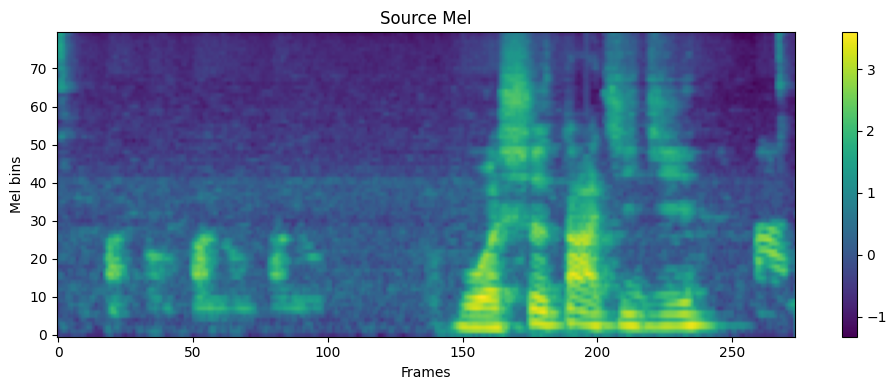


Reference audio:



Reference mel:


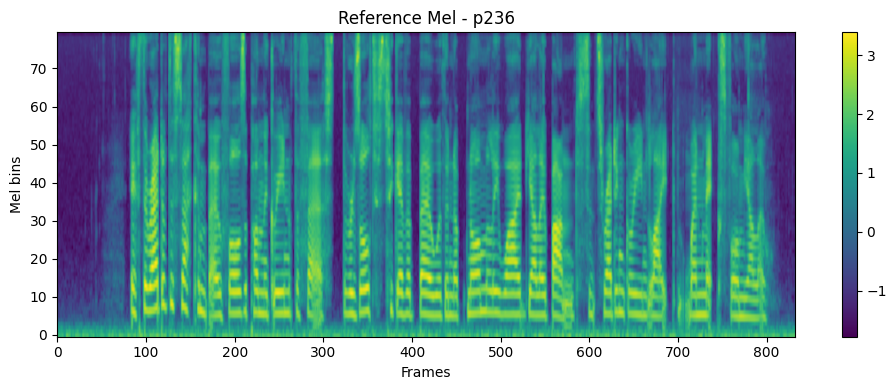


Converted audio:



Converted mel:


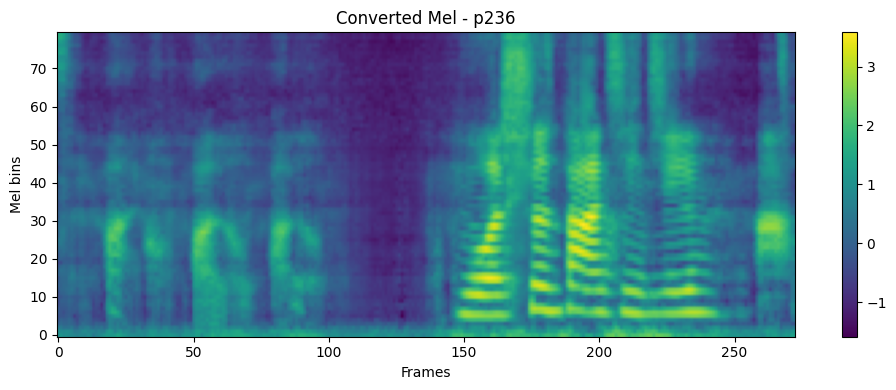


✅ Saved converted wav: /content/drive/MyDrive/Github/Accent-Conversion/Demo/converted_results/my_test_to_p236.wav


{'speaker': 'p236',
 'input_path': '/content/drive/MyDrive/Github/Accent-Conversion/Demo/live_inputs/my_test.wav',
 'output_path': '/content/drive/MyDrive/Github/Accent-Conversion/Demo/converted_results/my_test_to_p236.wav',
 'sample_rate': 24000}

In [36]:
ensure_preloaded_refs()
backend_record_and_convert(target_speaker='p236', filename='my_test.wav')

In [ ]:
# 1. 导入 Ngrok 官方的安全密钥
!curl -sSL https://ngrok-agent.s3.amazonaws.com/ngrok.asc | sudo tee /etc/apt/trusted.gpg.d/ngrok.asc >/dev/null

# 2. 将 Ngrok 源添加到系统
!echo "deb https://ngrok-agent.s3.amazonaws.com buster main" | sudo tee /etc/apt/sources.list.d/ngrok.list

# 3. 强制安装底层 Ngrok 程序
!sudo apt-get update -y
!sudo apt-get install ngrok -y

# 4. 验证安装
!ngrok version

## Cell 6 — WebSocket server + ngrok

In [ ]:
import os
test = os.path.join(WORK_DIR, 'VCTK-corpus/p228/p228_023.wav')
print(os.path.exists(test), test)

In [ ]:
import asyncio, json, shutil
from fastapi import FastAPI, WebSocket, WebSocketDisconnect
from pyngrok import ngrok, conf
import nest_asyncio
import uvicorn
import os
import subprocess
import shutil

app = FastAPI()

print('=============================================')
print('🚀 Building server...')
print('=============================================')

# ──────────────────────────────────────────────────────────────────
# Pre-load all reference mels at startup so clip switching is instant
# ──────────────────────────────────────────────────────────────────
PRELOADED_REFS = ensure_preloaded_refs()
DEFAULT_CLIP = list(PRELOADED_REFS.keys())[0]
print(f'Default: {DEFAULT_CLIP}')


# ──────────────────────────────────────────────────────────────────
# WebSocket endpoint
#
# Client -> Server protocol:
#   TEXT  {"cmd": "set_clip", "clip": "3"}        -- switch reference clip
#   TEXT  {"cmd": "infer"}                         -- next binary = mic audio
#   BINARY <webm bytes>                             -- mic recording
#
# Server -> Client protocol:
#   TEXT  {"status": "clip_ok",  "label": "p225 / clip 3"}
#   TEXT  {"status": "silence"}
#   TEXT  {"status": "error",    "message": "..."}
#   BINARY <converted wav bytes>
# ──────────────────────────────────────────────────────────────────
@app.websocket('/ws/vc')
async def ws_endpoint(websocket: WebSocket):
    await websocket.accept()
    print('[WS] 🟢 Client connected.')

    # Per-connection state
    current_clip   = DEFAULT_CLIP
    expect_infer   = False

    try:
        while True:
            message = await websocket.receive()

            # ── Binary: mic audio ──────────────────────────────────
            if 'bytes' in message and message['bytes'] is not None:
                if not expect_infer:
                    print('[WS] ⚠️  Unexpected binary (ignoring)')
                    continue
                expect_infer = False
                data = message['bytes']
                print(f'[WS] ▶️  Received audio ({len(data)} bytes), decoding...')

                # Decode webm -> PCM
                try:
                    samples = decode_webm_to_pcm(data)
                except Exception as e:
                    print(f'[WS] ❌ Decode error: {e}')
                    await websocket.send_text(json.dumps(
                        {'status': 'error', 'message': f'Audio decode failed: {e}'}))
                    continue

                print(f'  {len(samples)} samples  ({len(samples)/SAMPLE_RATE:.2f}s)')

                # VAD
                if is_silence(samples):
                    print('[WS] 😶 Silence — skipping')
                    await websocket.send_text(json.dumps({'status': 'silence'}))
                    continue

                # Inference
                ref_mel, domain_idx = PRELOADED_REFS[current_clip]
                print(f'[WS] ⚙️  Inferring  clip={current_clip}  domain={domain_idx}')
                try:
                    converted = run_inference(samples, ref_mel, domain_idx)
                except Exception as e:
                    import traceback; traceback.print_exc()
                    await websocket.send_text(json.dumps(
                        {'status': 'error', 'message': f'Inference error: {e}'}))
                    continue

                print('[WS] ✅ Done — sending converted audio')
                out_io = io.BytesIO()
                sf.write(out_io, converted, SAMPLE_RATE, format='WAV')
                await websocket.send_bytes(out_io.getvalue())
                continue

            # ── Text: JSON commands ───────────────────────────────
            if 'text' in message and message['text'] is not None:
                try:
                    msg = json.loads(message['text'])
                except Exception:
                    continue
                cmd = msg.get('cmd', '')

                if cmd == 'set_clip':
                    clip = str(msg.get('speaker', DEFAULT_CLIP))
                    if clip not in PRELOADED_REFS:
                        await websocket.send_text(json.dumps(
                            {'status': 'error',
                             'message': f'Clip {clip} not available (loaded: {list(PRELOADED_REFS.keys())})'
                            }))
                    else:
                        current_clip = clip
                        label = f'{clip}'
                        print(f'[WS] Reference → {label}')
                        await websocket.send_text(json.dumps(
                            {'status': 'clip_ok', 'label': label}))

                elif cmd == 'infer':
                    expect_infer = True

                else:
                    print(f'[WS] Unknown cmd: {cmd}')

    except WebSocketDisconnect:
        print('[WS] 🔴 Client disconnected.')
    except Exception as e:
        import traceback; traceback.print_exc()


# ──────────────────────────────────────────────────────────────────
# Start ngrok + uvicorn
# ──────────────────────────────────────────────────────────────────
nest_asyncio.apply()

print('📦 检查系统级 Ngrok 安装状态...')
if not os.path.exists('/usr/bin/ngrok'):
    print('⏳ 正在通过 APT 强制安装 ngrok，请稍等十几秒...')
    subprocess.run("curl -sSL https://ngrok-agent.s3.amazonaws.com/ngrok.asc | sudo tee /etc/apt/trusted.gpg.d/ngrok.asc >/dev/null", shell=True)
    subprocess.run("echo 'deb https://ngrok-agent.s3.amazonaws.com buster main' | sudo tee /etc/apt/sources.list.d/ngrok.list", shell=True)
    subprocess.run("sudo DEBIAN_FRONTEND=noninteractive apt-get update -y -qq", shell=True)
    subprocess.run("sudo DEBIAN_FRONTEND=noninteractive apt-get install ngrok -y -qq", shell=True)
    print('✅ 安装完成！')

# 获取绝对路径
ngrok_path = '/usr/bin/ngrok' if os.path.exists('/usr/bin/ngrok') else shutil.which('ngrok')

if not ngrok_path:
    print("❌ 致命错误：Ngrok 依然没有安装成功，请检查 Colab 网络。")
else:
    print(f"🔍 锁定 Ngrok 执行文件路径: {ngrok_path}")

    # 将 Token 写入系统内存环境变量，彻底绕过文件权限坑
    os.environ["NGROK_AUTHTOKEN"] = NGROK_AUTH_TOKEN

    # 💥 核心修复：创建一个绑死该路径的专属配置对象
    my_config = conf.PyngrokConfig(ngrok_path=ngrok_path)

    try:
        # 必须把 pyngrok_config 显式传给每一个 ngrok 操作！
        ngrok.kill(pyngrok_config=my_config)

        # 💥 就是这里！上一版漏了这句导致它又去瞎下载！
        kw = dict(pyngrok_config=my_config)
        if NGROK_DOMAIN:
            kw['domain'] = NGROK_DOMAIN

        tunnel = ngrok.connect(SERVER_PORT, **kw)
        ws_url = tunnel.public_url.replace('https://', 'wss://') + '/ws/vc'

        print('\n' + '='*60)
        print('✅ Tunnel ready!')
        print(f'👉 HTML WebSocket URL: {ws_url}')
        print('='*60 + '\n')
    except Exception as e:
        print(f'❌ Tunnel error: {e}')

print('🚀 Starting Uvicorn...')
uvi_cfg = uvicorn.Config(app, host='0.0.0.0', port=SERVER_PORT, log_level='info')
server  = uvicorn.Server(uvi_cfg)
await server.serve()